In [16]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image

# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [17]:
class SentinelState(TypedDict):
    ticker: str          # Input: e.g., "AAPL"
    data: str            # Intermediate: The raw "scraped" data
    analysis: str        # Output: The final summary

In [18]:
def data_fetcher_node(state: SentinelState):
    """Simulates fetching stock data from a database."""
    print(f"--- 🔍 Step 1: Fetching data for {state['ticker']} ---")

    # Simulating a mock database lookup
    mock_db = {
        "AAPL": "Price: $180, Trend: Bullish, Volume: High",
        "GOOGL": "Price: $140, Trend: Neutral, Volume: Average",
        "TSLA": "Price: $250, Trend: Bearish, Volume: Volatile"
    }

    fetched_info = mock_db.get(state['ticker'], "Data not found.")
    return {"data": fetched_info}

def analyst_node(state: SentinelState):
    """Simulates an AI analyzing the raw data."""
    print("--- 🧠 Step 2: Analyzing Data ---")

    raw_data = state['data']
    summary = f"Analysis Report: The stock is showing {raw_data.split('Trend: ')[1]} signals."
    return {"analysis": summary}

def formatter_node(state: SentinelState):
    """Simulates a final agent formatting the report for a user."""
    print("--- 📄 Step 3: Formatting Final Report ---")

    final_output = f"FINAL SENTINEL REPORT for {state['ticker']}\n{state['analysis'].upper()}"
    return {"analysis": final_output}

In [19]:
# 1. Initialize the Graph
builder = StateGraph(SentinelState)

# 2. Add our 'stations' (Nodes) to the line
builder.add_node("fetcher", data_fetcher_node)
builder.add_node("analyst", analyst_node)
builder.add_node("formatter", formatter_node)

# 3. Define the linear flow (Edges)
builder.add_edge(START, "fetcher")    # Start -> Fetcher
builder.add_edge("fetcher", "analyst") # Fetcher -> Analyst
builder.add_edge("analyst", "formatter") # Analyst -> Formatter
builder.add_edge("formatter", END)     # Formatter -> End

# 4. Compile the graph
sequential_line = builder.compile()

print("✅ Assembly Line Built & Compiled")

✅ Assembly Line Built & Compiled


In [20]:
# Input configuration
initial_input = {"ticker": "AAPL"}

# Run the graph
final_state = sequential_line.invoke(initial_input)

print("\n" + "="*30)
print(final_state['analysis'])
print("="*30)

--- 🔍 Step 1: Fetching data for AAPL ---
--- 🧠 Step 2: Analyzing Data ---
--- 📄 Step 3: Formatting Final Report ---

FINAL SENTINEL REPORT for AAPL
ANALYSIS REPORT: THE STOCK IS SHOWING BULLISH, VOLUME: HIGH SIGNALS.


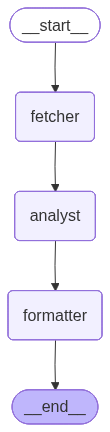

In [23]:
png_bytes = sequential_line.get_graph().draw_mermaid_png()

# Save to file
with open("sequential_line.png", "wb") as f:
    f.write(png_bytes)

# Display in notebook
display(Image(data=png_bytes))